In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
test_df = pd.read_csv('../data/test.csv')
train_df = pd.read_csv('../data/train.csv')

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

In [6]:
num_cols = train_df.select_dtypes(np.number).columns
cat_cols = train_df.select_dtypes(object).columns

print('numerical columns')
print(num_cols)
print('cat cols')
print(cat_cols)



numerical columns
Index(['id', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl',
       'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit',
       'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat',
       'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src',
       'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
       'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'label'],
      dtype='object')
cat cols
Index(['proto', 'service', 'state', 'attack_cat'], dtype='object')


In [7]:
num_cols= num_cols.drop(labels=['id', 'label'])

cat_cols = cat_cols.union(['label'])

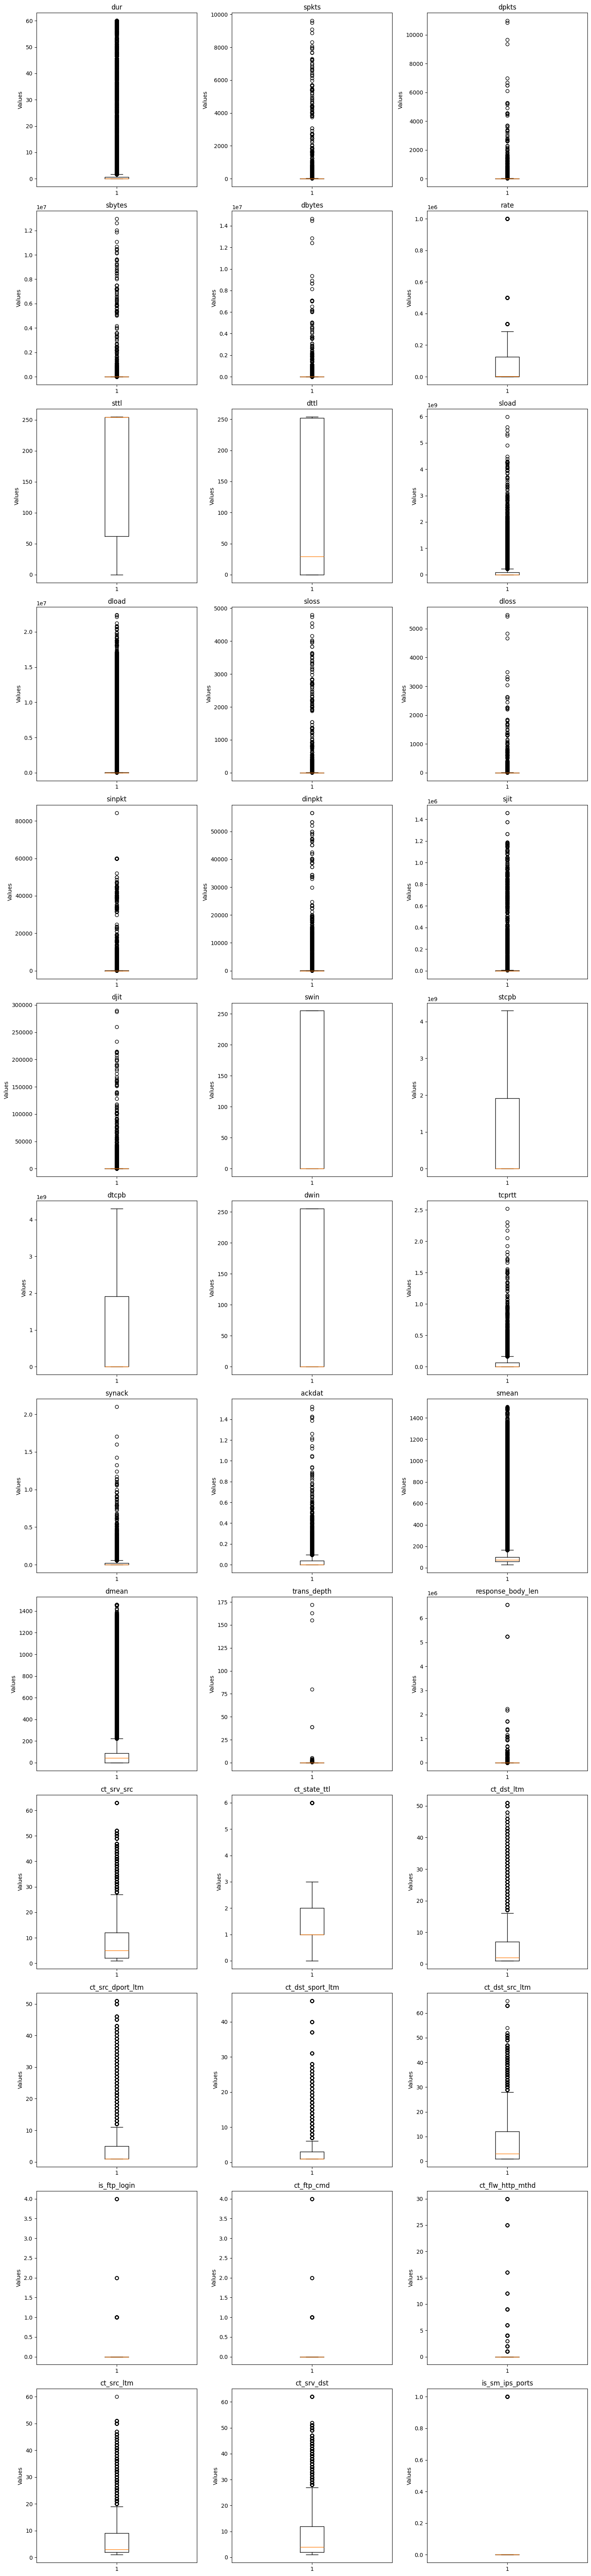

In [8]:
n = len(num_cols)
n_cols = 3 
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

if n_rows > 1 or n_cols > 1:
    axes = axes.flatten()
else:
    axes = [axes]

for i, col in enumerate(num_cols):
    if i < len(axes):
        axes[i].boxplot(train_df[col])
        axes[i].set_title(col)
        axes[i].set_ylabel('Values')

for i in range(len(num_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

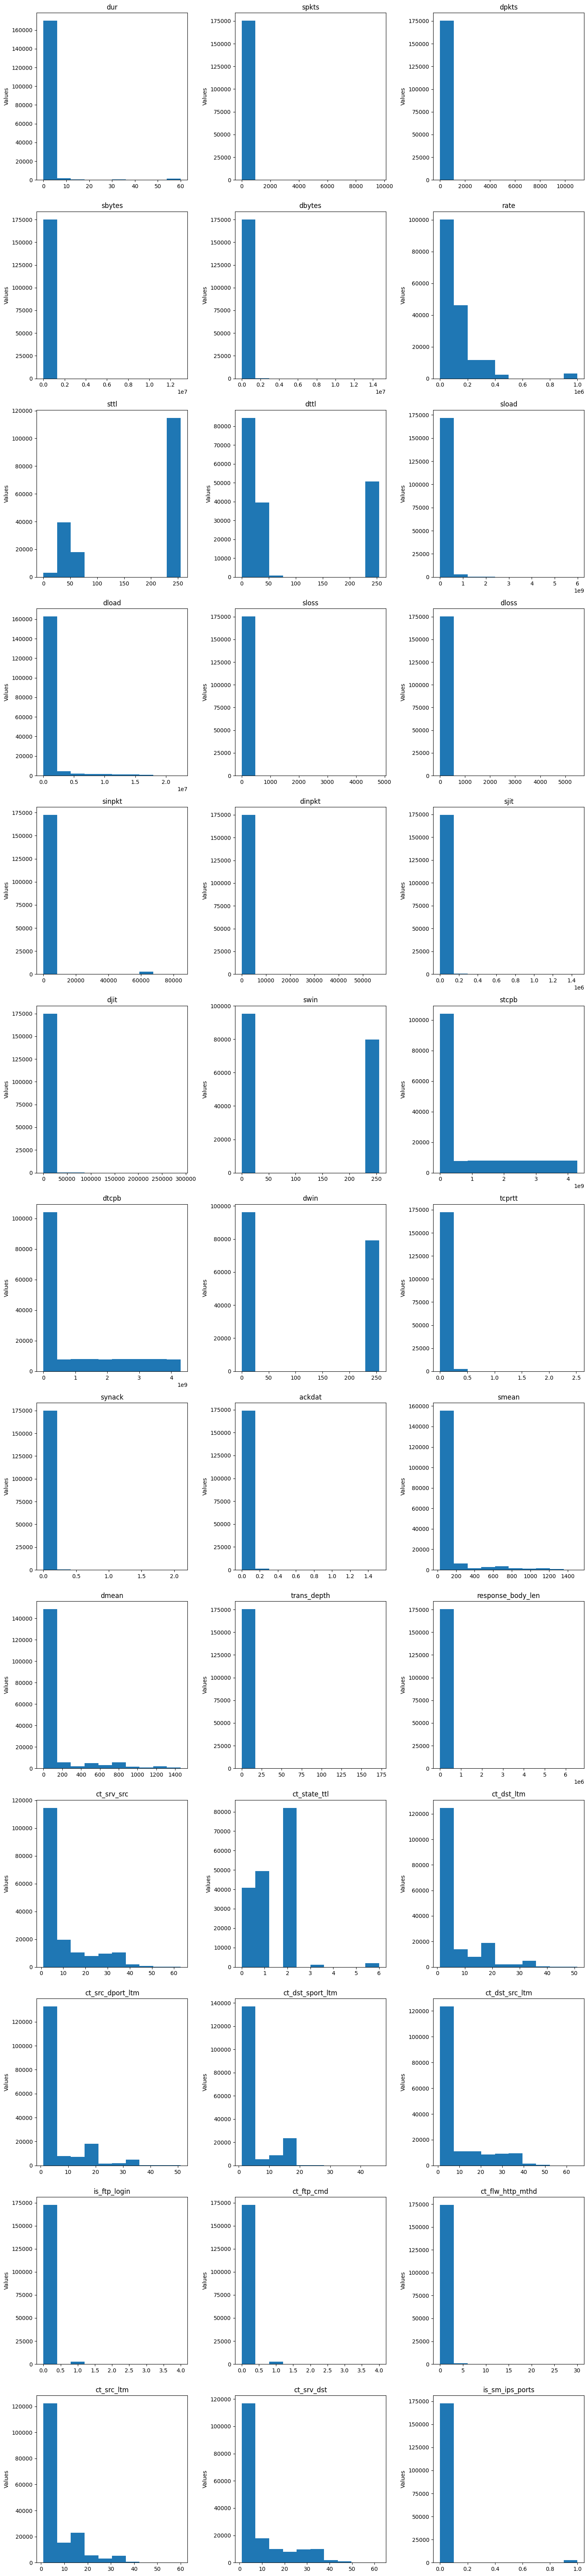

In [9]:
n = len(num_cols)
n_cols = 3 
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

if n_rows > 1 or n_cols > 1:
    axes = axes.flatten()
else:
    axes = [axes]

for i, col in enumerate(num_cols):
    if i < len(axes):
        axes[i].hist(train_df[col])
        axes[i].set_title(col)
        axes[i].set_ylabel('Values')

for i in range(len(num_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

heavy class imbalance in all, right tails, outliers present

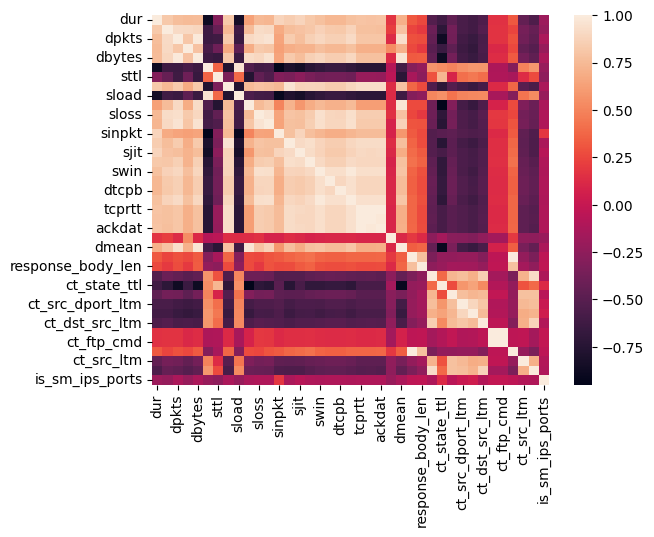

,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,...,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
dur,1.000000,0.821227,0.768716,0.751776,0.756663,-0.878607,-0.308375,0.818093,-0.843464,0.626905,...,-0.469445,-0.575185,-0.613127,-0.553023,0.156362,0.156362,0.318531,-0.454352,-0.549296,-0.192961
spkts,0.821227,1.000000,0.910312,0.901268,0.887752,-0.633582,-0.437480,0.748341,-0.619482,0.758160,...,-0.377132,-0.573132,-0.609922,-0.521446,0.162705,0.162705,0.245476,-0.370372,-0.436723,-0.222844
dpkts,0.768716,0.910312,1.000000,0.811971,0.989853,-0.638889,-0.630129,0.831565,-0.648749,0.905469,...,-0.381125,-0.609387,-0.659183,-0.576230,0.169384,0.169384,0.286882,-0.383949,-0.469458,-0.120801
sbytes,0.751776,0.901268,0.811971,1.000000,0.791584,-0.580769,-0.394910,0.678313,-0.470815,0.684038,...,-0.472880,-0.630632,-0.684698,-0.566761,0.111726,0.111726,0.255443,-0.449782,-0.509370,-0.216513
dbytes,0.756663,0.887752,0.989853,0.791584,1.000000,-0.634919,-0.661841,0.822699,-0.650389,0.922864,...,-0.373400,-0.613898,-0.659665,-0.578084,0.135172,0.135172,0.327776,-0.378203,-0.469037,-0.120727
rate,-0.878607,-0.633582,-0.638889,-0.580769,-0.634919,1.000000,0.362076,-0.775301,0.960351,-0.534157,...,0.503755,0.554989,0.586754,0.573807,-0.116821,-0.116821,-0.302673,0.496199,0.586329,-0.215340
sttl,-0.308375,-0.437480,-0.630129,-0.394910,-0.661841,0.362076,1.000000,-0.333361,0.389625,-0.765411,...,0.091453,0.407528,0.450252,0.400892,-0.110787,-0.110787,-0.139532,0.138366,0.263597,-0.255586
dttl,0.818093,0.748341,0.831565,0.678313,0.822699,-0.775301,-0.333361,1.000000,-0.771263,0.753277,...,-0.522525,-0.602678,-0.655640,-0.588248,0.122915,0.122915,0.374728,-0.504901,-0.570207,-0.123080
sload,-0.843464,-0.619482,-0.648749,-0.470815,-0.650389,0.960351,0.389625,-0.771263,1.000000,-0.558996,...,0.427520,0.497892,0.517045,0.524415,-0.137563,-0.137563,-0.302358,0.430718,0.526581,-0.215073
dload,0.626905,0.758160,0.905469,0.684038,0.922864,-0.534157,-0.765411,0.753277,-0.558996,1.000000,...,-0.304806,-0.596642,-0.663838,-0.552315,0.079421,0.079421,0.266471,-0.320064,-0.409442,-0.120684


In [10]:
corr_table = train_df[num_cols].corr(method='spearman')
heatmap = sns.heatmap(corr_table)
plt.show()
corr_table

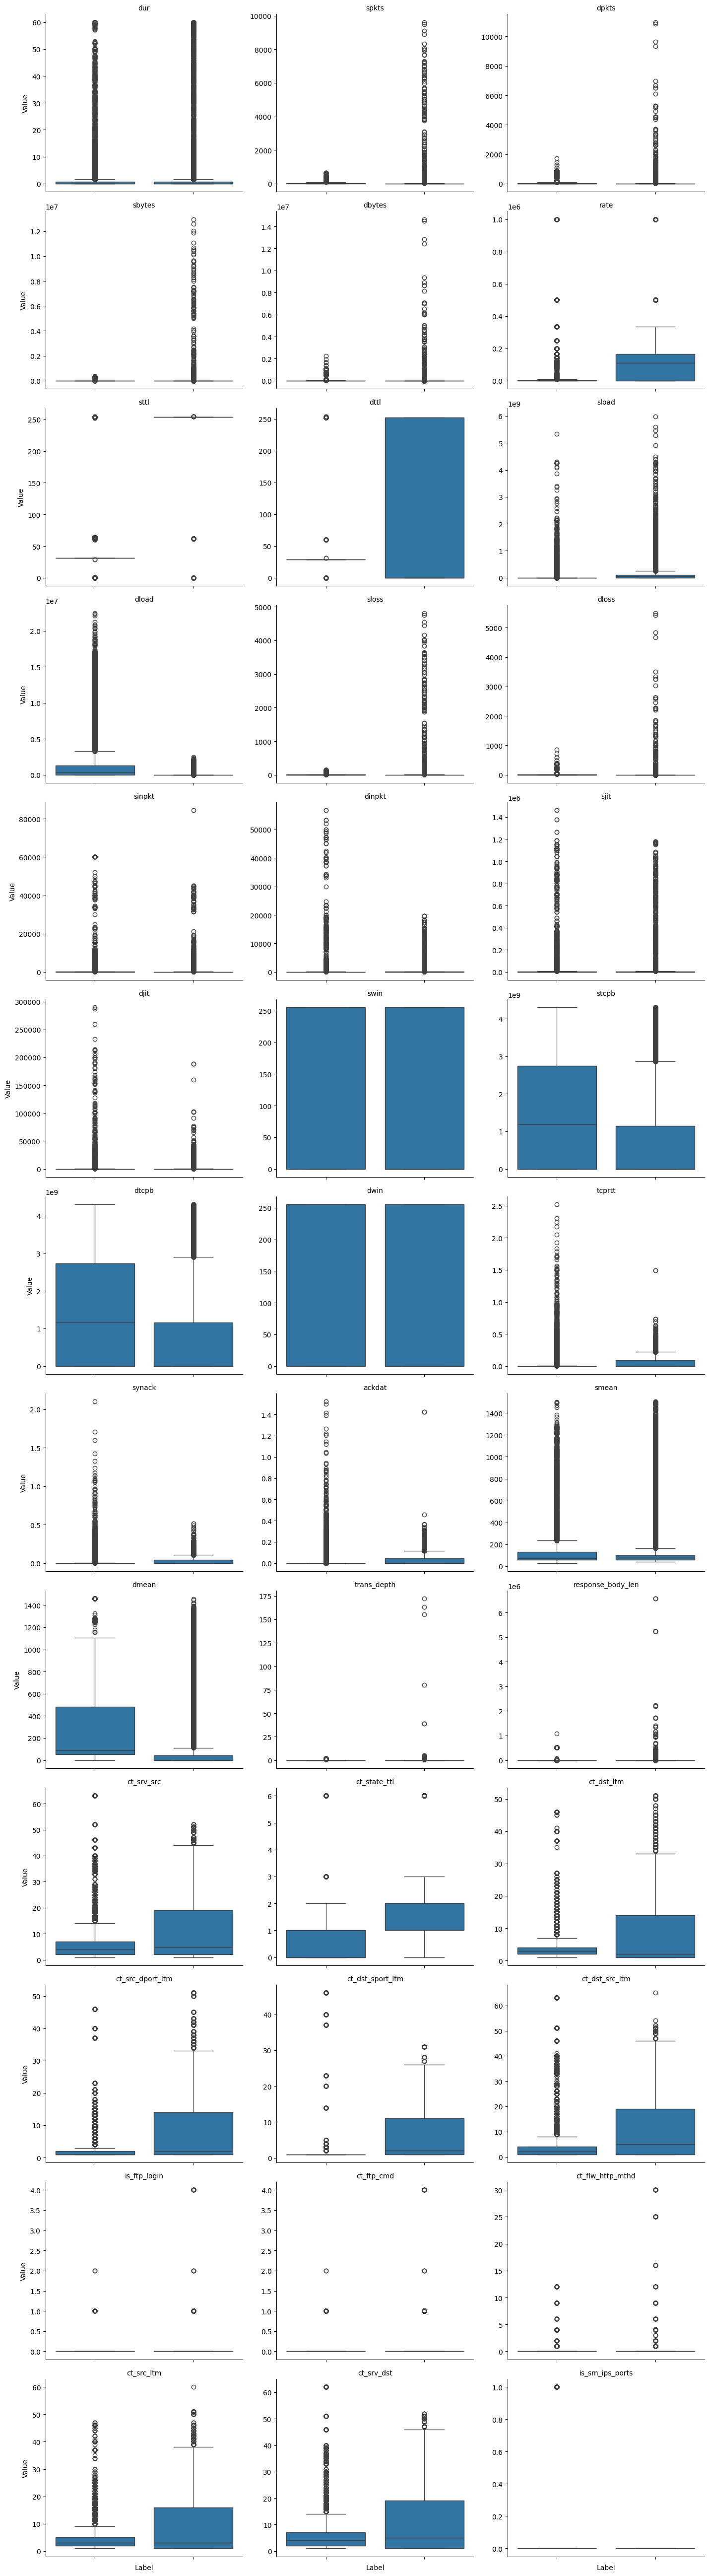

In [11]:
# Melt the DataFrame for seaborn
melted_df = pd.melt(train_df, 
                    id_vars=['label'], 
                    value_vars=num_cols,
                    var_name='feature', 
                    value_name='value')

# Create a FacetGrid
g = sns.FacetGrid(melted_df, col='feature', col_wrap=3, 
                  height=4, aspect=1.2, sharey=False)
g.map_dataframe(sns.boxplot, x='label', y='value')
g.set_titles("{col_name}")
g.set_axis_labels("Label", "Value")
g.set_xticklabels(rotation=45)

plt.tight_layout()
plt.show()

for label = 0, there are comparatively more outliers

In [12]:
train_df.isna().sum().sort_values(ascending=False)

id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports      0
attack_cat 

cleaned already

In [13]:
train_df = train_df.drop(columns=['id', 'attack_cat'])
test_df = test_df.drop(columns=['id', 'attack_cat'])

In [14]:
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']

X_test = test_df.drop(columns=['label'])
y_test = test_df['label']

In [15]:
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(exclude=['object', 'category']).columns.tolist()


In [16]:
from catboost import CatBoostClassifier

kitty = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=50,
    verbose=50,
    class_weights=[1,3]
)

kitty.fit(
    X_train,
    y_train,
    cat_features=cat_cols,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	test: 0.8596608	best: 0.8596608 (0)	total: 633ms	remaining: 5m 15s
50:	test: 0.9778021	best: 0.9778021 (50)	total: 22.2s	remaining: 3m 15s
100:	test: 0.9807920	best: 0.9808629 (96)	total: 42.2s	remaining: 2m 46s
150:	test: 0.9819387	best: 0.9819387 (150)	total: 1m 2s	remaining: 2m 25s
200:	test: 0.9824795	best: 0.9824795 (200)	total: 1m 23s	remaining: 2m 3s
250:	test: 0.9828423	best: 0.9828471 (247)	total: 1m 43s	remaining: 1m 42s
300:	test: 0.9829489	best: 0.9829518 (299)	total: 2m 4s	remaining: 1m 22s
350:	test: 0.9833135	best: 0.9833164 (349)	total: 2m 23s	remaining: 1m
400:	test: 0.9835169	best: 0.9835226 (399)	total: 2m 43s	remaining: 40.3s
450:	test: 0.9836649	best: 0.9836649 (450)	total: 3m 3s	remaining: 19.9s
499:	test: 0.9836621	best: 0.9836683 (451)	total: 3m 23s	remaining: 0us

bestTest = 0.9836683248
bestIteration = 451

Shrink model to first 452 iterations.


In [17]:
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

y_test_proba = kitty.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba > 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_test_proba))
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))


ROC-AUC: 0.9836683248036707
[[22056 14944]
 [   57 45275]]
              precision    recall  f1-score   support

           0       1.00      0.60      0.75     37000
           1       0.75      1.00      0.86     45332

    accuracy                           0.82     82332
   macro avg       0.87      0.80      0.80     82332
weighted avg       0.86      0.82      0.81     82332



In [18]:
thresholds = np.linspace(0.1, 0.9, 17)

for t in thresholds:
    preds = (y_test_proba > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    print(f"t={t:.2f} | FPR={fpr:.3f} | FNR={fnr:.4f}")


t=0.10 | FPR=0.425 | FNR=0.0000
t=0.15 | FPR=0.424 | FNR=0.0000
t=0.20 | FPR=0.424 | FNR=0.0000
t=0.25 | FPR=0.422 | FNR=0.0000
t=0.30 | FPR=0.422 | FNR=0.0000
t=0.35 | FPR=0.421 | FNR=0.0002
t=0.40 | FPR=0.418 | FNR=0.0005
t=0.45 | FPR=0.413 | FNR=0.0008
t=0.50 | FPR=0.404 | FNR=0.0013
t=0.55 | FPR=0.389 | FNR=0.0020
t=0.60 | FPR=0.367 | FNR=0.0033
t=0.65 | FPR=0.339 | FNR=0.0054
t=0.70 | FPR=0.304 | FNR=0.0089
t=0.75 | FPR=0.259 | FNR=0.0143
t=0.80 | FPR=0.206 | FNR=0.0240
t=0.85 | FPR=0.156 | FNR=0.0370
t=0.90 | FPR=0.106 | FNR=0.0577


In [19]:
y_test_proba = kitty.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba>0.75).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_test_proba))
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))


ROC-AUC: 0.9836683248036707
[[27416  9584]
 [  647 44685]]
              precision    recall  f1-score   support

           0       0.98      0.74      0.84     37000
           1       0.82      0.99      0.90     45332

    accuracy                           0.88     82332
   macro avg       0.90      0.86      0.87     82332
weighted avg       0.89      0.88      0.87     82332



In [20]:
import torch
import torch.nn as nn
from sklearn.preprocessing import RobustScaler, LabelEncoder



In [21]:
AE_df_train = train_df[train_df['label'] == 0].copy()
AE_df_test  = test_df[test_df['label'] == 0].copy()

DROP_COLS = ['label']
X_AE_train = AE_df_train.drop(columns=DROP_COLS)
X_AE_test  = AE_df_test.drop(columns=DROP_COLS)


In [22]:
scaler = RobustScaler()

X_AE_train_num = scaler.fit_transform(X_AE_train[num_cols])
X_AE_test_num  = scaler.transform(X_AE_test[num_cols])


In [23]:
cat_encoders = {}
train_cat_idxs = []
test_cat_idxs = []

for col in cat_cols:
    le = LabelEncoder()

    # Fit ONLY on normal training categories
    train_vals = X_AE_train[col].astype(str)
    le.fit(train_vals)

    # Add UNK token explicitly
    classes = list(le.classes_)
    if 'UNK' not in classes:
        classes.append('UNK')
        le.classes_ = np.array(classes)

    # Transform TRAIN
    train_idx = le.transform(train_vals)

    # Transform TEST with UNK fallback
    test_vals = X_AE_test[col].astype(str)
    unk_idx = le.transform(['UNK'])[0]

    test_idx = np.array([
        le.transform([v])[0] if v in le.classes_ else unk_idx
        for v in test_vals
    ])

    cat_encoders[col] = le
    train_cat_idxs.append(train_idx.reshape(-1, 1))
    test_cat_idxs.append(test_idx.reshape(-1, 1))

train_cat_idxs = np.hstack(train_cat_idxs)
test_cat_idxs  = np.hstack(test_cat_idxs)


In [24]:
cat_cardinalities = [len(cat_encoders[col].classes_) for col in cat_cols]
emb_dims = [min(8, max(2, c // 2)) for c in cat_cardinalities]


In [25]:
train_NUM = torch.tensor(X_AE_train_num, dtype=torch.float32)
test_NUM  = torch.tensor(X_AE_test_num, dtype=torch.float32)

train_CAT = torch.tensor(train_cat_idxs, dtype=torch.long)
test_CAT  = torch.tensor(test_cat_idxs, dtype=torch.long)


In [26]:
class EmbeddedAutoEncoder(nn.Module):
    def __init__(self, num_numeric, cat_cards, emb_dims):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(card, dim)
            for card, dim in zip(cat_cards, emb_dims)
        ])

        emb_total = sum(emb_dims)
        input_dim = num_numeric + emb_total

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16)
        )

        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim)
        )

    def forward(self, x_num, x_cat):
        embeds = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat([x_num] + embeds, dim=1)
        z = self.encoder(x)
        return self.decoder(z)


In [27]:
model = EmbeddedAutoEncoder(
    num_numeric=train_NUM.shape[1],
    cat_cards=cat_cardinalities,
    emb_dims=emb_dims
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()


In [28]:
model.train()
EPOCHS = 30
for epoch in range(EPOCHS):
    optimizer.zero_grad()

    recon = model(train_NUM, train_CAT)

    # Build full input (numeric + embeddings)
    with torch.no_grad():
        emb_parts = [model.embeddings[i](train_CAT[:, i])
                     for i in range(len(model.embeddings))]
        full_input = torch.cat([train_NUM] + emb_parts, dim=1)

    loss = criterion(recon, full_input)
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        print(f"Epoch {epoch:02d} | Loss = {loss.item():.6f}")


Epoch 00 | Loss = 36165664.000000
Epoch 05 | Loss = 35944184.000000
Epoch 10 | Loss = 34372232.000000
Epoch 15 | Loss = 26670876.000000
Epoch 20 | Loss = 3589143.750000
Epoch 25 | Loss = 4522824.000000


In [29]:
model.eval()
with torch.no_grad():
    # TRAIN scores (baseline)
    recon_train = model(train_NUM, train_CAT)
    emb_parts_train = [model.embeddings[i](train_CAT[:, i])
                       for i in range(len(model.embeddings))]
    full_train = torch.cat([train_NUM] + emb_parts_train, dim=1)

    train_scores = torch.mean((recon_train - full_train) ** 2, dim=1)

    # TEST scores (normal-only test for now)
    recon_test = model(test_NUM, test_CAT)
    emb_parts_test = [model.embeddings[i](test_CAT[:, i])
                      for i in range(len(model.embeddings))]
    full_test = torch.cat([test_NUM] + emb_parts_test, dim=1)

    test_scores = torch.mean((recon_test - full_test) ** 2, dim=1)

print("Train anomaly score mean:", train_scores.mean().item())
print("Test anomaly score mean :", test_scores.mean().item())


Train anomaly score mean: 2309535.75
Test anomaly score mean : 1387148.0


In [30]:
print("Train percentiles:")
print(np.percentile(train_scores.numpy(), [50, 75, 90, 95, 99]))

print("\nTest-normal percentiles:")
print(np.percentile(test_scores.numpy(), [50, 75, 90, 95, 99]))

Train percentiles:
[2.94047725e+00 5.21666003e+03 1.83042152e+04 2.08971133e+04
 1.31034824e+05]

Test-normal percentiles:
[  1467.03717041   8138.01306152  18300.73671875  21964.67646484
 178955.423125  ]


In [31]:
# Attack-only test data
AE_attack_df = test_df[test_df['label'] == 1].copy()

X_AE_attack = AE_attack_df.drop(columns=['label'])

# Numerical scaling (USE SAME SCALER)
X_AE_attack_num = scaler.transform(X_AE_attack[num_cols])


In [32]:
attack_cat_idxs = []

for col in cat_cols:
    le = cat_encoders[col]
    unk_idx = le.transform(['UNK'])[0]

    attack_vals = X_AE_attack[col].astype(str)

    idx = np.array([
        le.transform([v])[0] if v in le.classes_ else unk_idx
        for v in attack_vals
    ])

    attack_cat_idxs.append(idx.reshape(-1, 1))

attack_cat_idxs = np.hstack(attack_cat_idxs)


In [33]:
attack_NUM = torch.tensor(X_AE_attack_num, dtype=torch.float32)
attack_CAT = torch.tensor(attack_cat_idxs, dtype=torch.long)


Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU

PREPROCESSING: SCALING & SEQUENCING
Scaling numerical features with MinMaxScaler (0-1)...
Creating sequences (Length=30)...
Train sequences: (11195, 30, 39)
Test sequences:  (7395, 30, 39)
Attack sequences: (9061, 30, 39)

TRAINING WITH L1 LOSS (MAE)
Model Parameters: 938,238
Epoch 01 | Train Loss: 0.20914 (Recon: 0.20901) | Val Loss: 0.17828
Epoch 02 | Train Loss: 0.16315 (Recon: 0.16314) | Val Loss: 0.15255
Epoch 03 | Train Loss: 0.13700 (Recon: 0.13700) | Val Loss: 0.12723
Epoch 04 | Train Loss: 0.11242 (Recon: 0.11242) | Val Loss: 0.10559
Epoch 05 | Train Loss: 0.09267 (Recon: 0.09267) | Val Loss: 0.08919
Epoch 06 | Train Loss: 0.08038 (Recon: 0.08037) | Val Loss: 0.07904
Epoch 07 | Train Loss: 0.07035 (Recon: 0.07035) | Val Loss: 0.06553
Epoch 08 | Train Loss: 0.06300 (Recon: 0.06298) | Val Loss: 0.05876
Epoch 09 | Train Loss: 0.05718 (Recon: 0.05718) | Val Loss: 0.05425
Epoch 10 | Train Loss: 0.05284 (Recon: 0.05284) | V

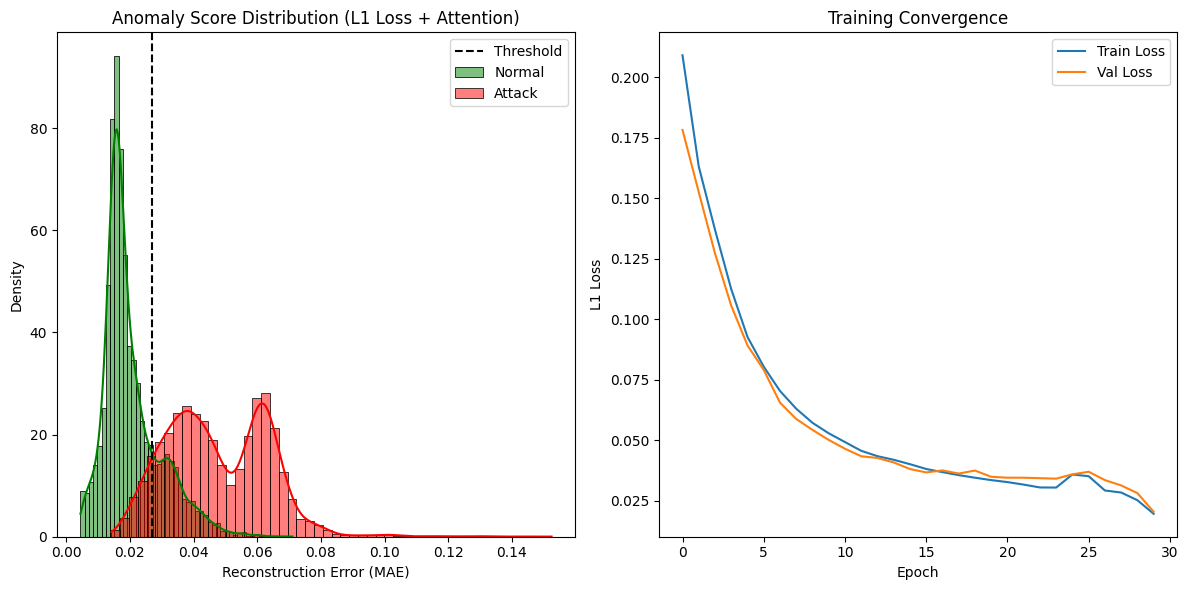

Model and Scaler saved.


In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import seaborn as sns
import joblib

# ==================== SET DEVICE ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ==================== 1. IMPROVED DATA PREPARATION ====================

def create_sequences(data, sequence_length=30, step=1):
    """Create sequences with configurable step size"""
    sequences = []
    n_samples = len(data)
    
    for i in range(0, n_samples - sequence_length + 1, step):
        seq = data[i:i+sequence_length]
        if len(seq) == sequence_length:
            sequences.append(seq)
    
    if len(sequences) == 0:
        return np.array([]).reshape(0, sequence_length, -1)
    return np.array(sequences)

print("\n" + "="*60)
print("PREPROCESSING: SCALING & SEQUENCING")
print("="*60)

# CONFIGURATION
# Increased sequence length to capture attack context better
SEQUENCE_LENGTH = 30 
STEP_SIZE = 5

# CHANGE: Use MinMaxScaler to preserve spike magnitude (critical for attacks)
# Attacks often manifest as extreme values; QuantileTransformer was squashing them.
scaler = MinMaxScaler(feature_range=(0, 1))

print("Scaling numerical features with MinMaxScaler (0-1)...")
# Fit on train, transform all
X_AE_train_num_scaled = scaler.fit_transform(X_AE_train[num_cols])
X_AE_test_num_scaled = scaler.transform(X_AE_test[num_cols])
X_AE_attack_num_scaled = scaler.transform(X_AE_attack[num_cols])

print(f"Creating sequences (Length={SEQUENCE_LENGTH})...")

# Create sequences for Numeric Data
train_seq_num = create_sequences(X_AE_train_num_scaled, SEQUENCE_LENGTH, STEP_SIZE)
test_seq_num = create_sequences(X_AE_test_num_scaled, SEQUENCE_LENGTH, STEP_SIZE)
attack_seq_num = create_sequences(X_AE_attack_num_scaled, SEQUENCE_LENGTH, STEP_SIZE)

# Create sequences for Categorical Data
train_seq_cat = create_sequences(train_cat_idxs, SEQUENCE_LENGTH, STEP_SIZE)
test_seq_cat = create_sequences(test_cat_idxs, SEQUENCE_LENGTH, STEP_SIZE)
attack_seq_cat = create_sequences(attack_cat_idxs, SEQUENCE_LENGTH, STEP_SIZE)

print(f"Train sequences: {train_seq_num.shape}")
print(f"Test sequences:  {test_seq_num.shape}")
print(f"Attack sequences: {attack_seq_num.shape}")

# Create DataLoaders
# Slightly larger batch size for stability with L1 loss
BATCH_SIZE = 64

train_dataset = TensorDataset(torch.tensor(train_seq_num, dtype=torch.float32), 
                              torch.tensor(train_seq_cat, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(test_seq_num, dtype=torch.float32), 
                             torch.tensor(test_seq_cat, dtype=torch.long))
attack_dataset = TensorDataset(torch.tensor(attack_seq_num, dtype=torch.float32), 
                               torch.tensor(attack_seq_cat, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
attack_loader = DataLoader(attack_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ==================== 2. LSTM-VAE WITH ATTENTION ====================

class Attention(nn.Module):
    """
    Computes attention weights to help the decoder focus on specific 
    encoder timesteps.
    """
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        # Linear layer to calculate energy scores
        # Input: decoder_hidden (hidden_dim) + encoder_output (hidden_dim)
        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: [batch, hidden_dim]
        # encoder_outputs: [batch, seq_len, hidden_dim]
        
        seq_len = encoder_outputs.shape[1]
        
        # Repeat decoder hidden state seq_len times
        hidden_expanded = hidden.unsqueeze(1).repeat(1, seq_len, 1)
        
        # Calculate energy
        energy = torch.tanh(self.attn(torch.cat((hidden_expanded, encoder_outputs), dim=2)))
        
        # Calculate attention weights
        attention = self.v(energy).squeeze(2)
        return F.softmax(attention, dim=1)

class LSTM_VAE_Attention(nn.Module):
    def __init__(self, num_numeric, cat_cards, emb_dims, hidden_dim=128, latent_dim=32):
        super(LSTM_VAE_Attention, self).__init__()
        
        self.num_numeric = num_numeric
        self.emb_dims = emb_dims
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        
        # 1. Embeddings
        self.embeddings = nn.ModuleList([
            nn.Embedding(card, dim) for card, dim in zip(cat_cards, emb_dims)
        ])
        self.input_dim = num_numeric + sum(emb_dims)
        
        # 2. Encoder (Bidirectional)
        # We use bidirectional to capture context from both directions
        self.encoder_lstm = nn.LSTM(
            input_size=self.input_dim, 
            hidden_size=hidden_dim, 
            batch_first=True, 
            bidirectional=True
        )
        
        # 3. Latent Space Projections
        # Input is hidden_dim * 2 because of bidirectional encoder
        self.fc_mu = nn.Linear(hidden_dim * 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim * 2, latent_dim)
        
        # 4. Decoder Setup
        # Map latent vector to decoder initial state
        self.decoder_input_map = nn.Linear(latent_dim, hidden_dim * 2)
        
        # Attention Mechanism
        self.attention = Attention(hidden_dim * 2)
        
        # Decoder LSTM
        self.decoder_lstm = nn.LSTM(
            input_size=self.input_dim + hidden_dim * 2, # input + context
            hidden_size=hidden_dim * 2, 
            batch_first=True
        )
        
        # 5. Reconstruction
        self.fc_recon = nn.Sequential(
            nn.Linear(hidden_dim * 2, self.input_dim),
            nn.Sigmoid() # Sigmoid forces output to [0,1], matching MinMaxScaler
        )
        
    def encode(self, x_num, x_cat):
        # Create embeddings
        embeds_list = []
        for t in range(x_num.shape[1]):
            emb_t = [emb(x_cat[:, t, i]) for i, emb in enumerate(self.embeddings)]
            embeds_list.append(torch.cat(emb_t, dim=1))
        
        # Combine numeric + embeddings
        x_combined = torch.cat([x_num, torch.stack(embeds_list, dim=1)], dim=2)
        
        # Encoder Pass
        # encoder_outputs: [batch, seq_len, hidden_dim * 2]
        # hidden: [2, batch, hidden_dim]
        encoder_outputs, (hidden, cell) = self.encoder_lstm(x_combined)
        
        # Concatenate the final forward and backward hidden states
        hidden_combined = torch.cat((hidden[-2], hidden[-1]), dim=1)
        
        # Latent variables
        mu = self.fc_mu(hidden_combined)
        logvar = self.fc_logvar(hidden_combined)
        
        return mu, logvar, encoder_outputs, x_combined

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, encoder_outputs, target_seq):
        batch_size, seq_len, _ = encoder_outputs.shape
        
        # Initialize decoder hidden state from latent vector
        decoder_hidden = self.decoder_input_map(z)
        h_state = decoder_hidden.unsqueeze(0)
        c_state = torch.zeros_like(h_state)
        
        recon_outputs = []
        
        # Use Teacher Forcing during training (feed real previous step)
        # or previous output during inference. 
        # Here we simply use the latent projection as the "start token" equivalent
        # or implement a simpler loop without teacher forcing for VAE purity.
        
        # For this implementation: Feed concatenation of (Context + Previous Input)
        # We initialize "previous input" as zeros for the first step
        decoder_input = torch.zeros(batch_size, 1, self.input_dim).to(device)
        
        for t in range(seq_len):
            # 1. Calculate Attention Weights
            attn_weights = self.attention(h_state.squeeze(0), encoder_outputs)
            
            # 2. Calculate Context Vector (Weighted sum of encoder outputs)
            context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)
            
            # 3. Concatenate Context with Input
            rnn_input = torch.cat((decoder_input, context), dim=2)
            
            # 4. LSTM Step
            out, (h_state, c_state) = self.decoder_lstm(rnn_input, (h_state, c_state))
            
            # 5. Predict Output
            prediction = self.fc_recon(out)
            recon_outputs.append(prediction)
            
            # Prepare input for next step
            # Teacher forcing: use actual input from t (if available)
            # OR use prediction. Standard VAE often uses the target sequence as input.
            if self.training and target_seq is not None:
                decoder_input = target_seq[:, t].unsqueeze(1)
            else:
                decoder_input = prediction # Autoregressive
            
        return torch.cat(recon_outputs, dim=1)

    def forward(self, x_num, x_cat):
        mu, logvar, encoder_outputs, x_combined = self.encode(x_num, x_cat)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, encoder_outputs, x_combined)
        return recon, mu, logvar, x_combined

# ==================== 3. TRAINING WITH L1 LOSS ====================

print("\n" + "="*60)
print("TRAINING WITH L1 LOSS (MAE)")
print("="*60)

# Initialize Model
model = LSTM_VAE_Attention(
    num_numeric=len(num_cols),
    cat_cards=cat_cardinalities,
    emb_dims=emb_dims,
    hidden_dim=128,    # Good capacity
    latent_dim=32      # Sufficient latent space
).to(device)

print(f"Model Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# L1 Loss function (Sharper reconstruction than MSE)
def loss_function(recon_x, x, mu, logvar, beta=0.005):
    # Reconstruction Loss: L1 (MAE)
    recon_loss = F.l1_loss(recon_x, x, reduction='mean')
    
    # KL Divergence
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

# Training Loop
epochs = 30
best_loss = float('inf')
patience = 5
counter = 0

train_history = []
val_history = []

for epoch in range(epochs):
    model.train()
    train_loss = 0
    train_recon = 0
    
    for b_num, b_cat in train_loader:
        b_num, b_cat = b_num.to(device), b_cat.to(device)
        
        optimizer.zero_grad()
        recon, mu, logvar, target = model(b_num, b_cat)
        
        loss, r_loss, k_loss = loss_function(recon, target, mu, logvar)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        train_recon += r_loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for b_num, b_cat in test_loader:
            b_num, b_cat = b_num.to(device), b_cat.to(device)
            recon, mu, logvar, target = model(b_num, b_cat)
            loss, _, _ = loss_function(recon, target, mu, logvar)
            val_loss += loss.item()
            
    avg_val_loss = val_loss / len(test_loader)
    scheduler.step(avg_val_loss)
    
    print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.5f} (Recon: {train_recon/len(train_loader):.5f}) | Val Loss: {avg_val_loss:.5f}")
    
    train_history.append(avg_train_loss)
    val_history.append(avg_val_loss)
    
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_lstm_attn_model.pth')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early Stopping!")
            break

# Load best
model.load_state_dict(torch.load('best_lstm_attn_model.pth'))

# ==================== 4. EVALUATION & SCORING ====================

print("\n" + "="*60)
print("EVALUATION")
print("="*60)

def get_anomaly_scores(loader, model):
    model.eval()
    scores = []
    with torch.no_grad():
        for b_num, b_cat in loader:
            b_num, b_cat = b_num.to(device), b_cat.to(device)
            recon, mu, logvar, target = model(b_num, b_cat)
            
            # Calculate error per sequence (L1 Error)
            # [batch, seq_len, input_dim]
            error_tensor = torch.abs(recon - target)
            
            # Mean over sequence and features
            seq_error = torch.mean(error_tensor, dim=[1, 2])
            
            # Add small KL penalty
            kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
            
            score = seq_error + 0.005 * kl
            scores.extend(score.cpu().numpy())
    return np.array(scores)

print("Calculating scores...")
train_scores = get_anomaly_scores(train_loader, model)
test_scores = get_anomaly_scores(test_loader, model)
attack_scores = get_anomaly_scores(attack_loader, model)

print(f"Normal Score Mean: {test_scores.mean():.4f} +/- {test_scores.std():.4f}")
print(f"Attack Score Mean: {attack_scores.mean():.4f} +/- {attack_scores.std():.4f}")

# ==================== 5. THRESHOLD OPTIMIZATION ====================

def find_optimal_threshold(normal_scores, attack_scores):
    # Combine scores and create labels
    y_true = np.concatenate([np.zeros(len(normal_scores)), np.ones(len(attack_scores))])
    y_scores = np.concatenate([normal_scores, attack_scores])
    
    # Sort scores to use as thresholds
    thresholds = np.linspace(np.min(y_scores), np.max(y_scores), 1000)
    
    best_j = -1
    best_thresh = 0
    best_metrics = {}
    
    for thresh in thresholds:
        tp = np.sum(attack_scores > thresh)
        fp = np.sum(normal_scores > thresh)
        tn = np.sum(normal_scores <= thresh)
        fn = np.sum(attack_scores <= thresh)
        
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0 # Recall
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        
        # Youden's J statistic
        j = tpr - fpr
        
        if j > best_j:
            best_j = j
            best_thresh = thresh
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            f1 = 2 * (precision * tpr) / (precision + tpr) if (precision + tpr) > 0 else 0
            best_metrics = {
                'TPR': tpr, 'FPR': fpr, 'Precision': precision, 'F1': f1
            }
            
    return best_thresh, best_metrics

print("Optimizing threshold...")
optimal_thresh, metrics = find_optimal_threshold(test_scores, attack_scores)

print(f"\nOPTIMAL RESULTS:")
print(f"Threshold: {optimal_thresh:.6f}")
print(f"Detection Rate (Recall): {metrics['TPR']:.2%}")
print(f"False Positive Rate:     {metrics['FPR']:.2%}")
print(f"Precision:               {metrics['Precision']:.2%}")
print(f"F1 Score:                {metrics['F1']:.4f}")

# ==================== 6. VISUALIZATION ====================

plt.figure(figsize=(12, 6))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(test_scores, color='green', label='Normal', kde=True, stat="density", bins=50)
sns.histplot(attack_scores, color='red', label='Attack', kde=True, stat="density", bins=50)
plt.axvline(optimal_thresh, color='black', linestyle='--', label='Threshold')
plt.title('Anomaly Score Distribution (L1 Loss + Attention)')
plt.xlabel('Reconstruction Error (MAE)')
plt.legend()

# Training History
plt.subplot(1, 2, 2)
plt.plot(train_history, label='Train Loss')
plt.plot(val_history, label='Val Loss')
plt.title('Training Convergence')
plt.xlabel('Epoch')
plt.ylabel('L1 Loss')
plt.legend()

plt.tight_layout()
plt.show()

# ==================== SAVE ARTIFACTS ====================
joblib.dump(scaler, 'minmax_scaler.pkl')
torch.save(model.state_dict(), 'lstm_attention_final.pth')
print("Model and Scaler saved.")


POST-PROCESSING: SCORE SMOOTHING
Applying rolling average (Window=5)...

Optimizing Threshold with 5% FPR Limit...

FINAL RESULTS (Smoothed & Constrained):
Threshold:       0.037679
Detection Rate:  70.89% (Goal: >90%)
False Positive:  4.84% (Goal: <5%)


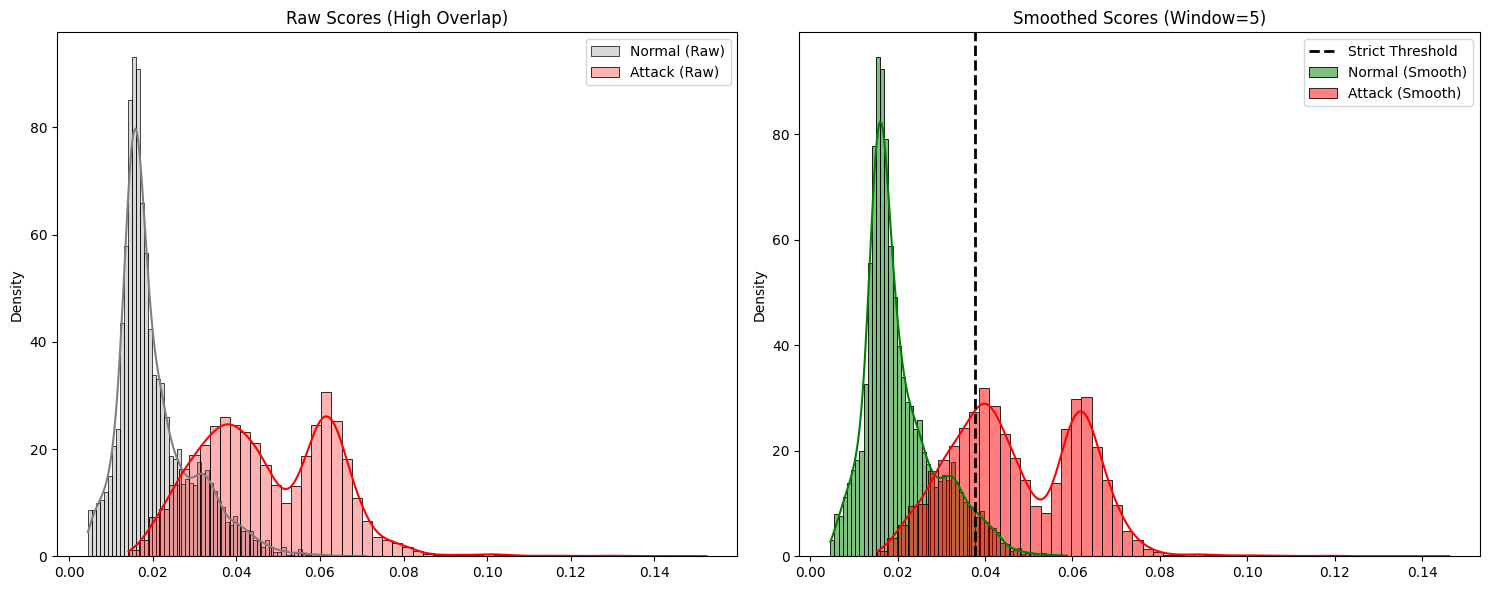


Decision engine saved.


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*60)
print("POST-PROCESSING: SCORE SMOOTHING")
print("="*60)

def smooth_scores(scores, window_size=5):
    """
    Apply moving average to smooth out transient noise spikes.
    This suppresses False Positives caused by single-packet anomalies.
    """
    series = pd.Series(scores)
    # Rolling mean, min_periods=1 keeps the start of the sequence valid
    smoothed = series.rolling(window=window_size, min_periods=1).mean().values
    return smoothed

# 1. Apply Smoothing
WINDOW_SIZE = 5  # Look at average of last 5 sequences
print(f"Applying rolling average (Window={WINDOW_SIZE})...")

smooth_test_scores = smooth_scores(test_scores, WINDOW_SIZE)
smooth_attack_scores = smooth_scores(attack_scores, WINDOW_SIZE)

# 2. Re-Optimize Threshold on Smoothed Scores
def find_strict_threshold(normal_scores, attack_scores, max_fpr=0.05):
    """
    Find best threshold but HARD LIMIT the False Positive Rate to 5%.
    """
    # Define candidate thresholds based on Normal distribution percentiles
    # We want to be above the 95th percentile of normal data
    start_thresh = np.percentile(normal_scores, 95)
    end_thresh = np.max(normal_scores) # Only scan the upper tail
    
    thresholds = np.linspace(start_thresh, max(np.max(attack_scores), end_thresh), 500)
    
    best_tpr = 0
    best_thresh = thresholds[0]
    best_fpr = 1.0
    
    for thresh in thresholds:
        tpr = np.mean(attack_scores > thresh)
        fpr = np.mean(normal_scores > thresh)
        
        if fpr <= max_fpr:
            if tpr > best_tpr:
                best_tpr = tpr
                best_thresh = thresh
                best_fpr = fpr
    
    return best_thresh, best_tpr, best_fpr

print("\nOptimizing Threshold with 5% FPR Limit...")
thresh, tpr, fpr = find_strict_threshold(smooth_test_scores, smooth_attack_scores, max_fpr=0.05)

print(f"\nFINAL RESULTS (Smoothed & Constrained):")
print(f"Threshold:       {thresh:.6f}")
print(f"Detection Rate:  {tpr:.2%} (Goal: >90%)")
print(f"False Positive:  {fpr:.2%} (Goal: <5%)")

# 3. Visual Comparison
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(test_scores, color='gray', label='Normal (Raw)', alpha=0.3, kde=True, stat='density')
sns.histplot(attack_scores, color='red', label='Attack (Raw)', alpha=0.3, kde=True, stat='density')
plt.title("Raw Scores (High Overlap)")
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(smooth_test_scores, color='green', label='Normal (Smooth)', alpha=0.5, kde=True, stat='density')
sns.histplot(smooth_attack_scores, color='red', label='Attack (Smooth)', alpha=0.5, kde=True, stat='density')
plt.axvline(thresh, color='black', linestyle='--', linewidth=2, label='Strict Threshold')
plt.title(f"Smoothed Scores (Window={WINDOW_SIZE})")
plt.legend()

plt.tight_layout()
plt.show()

# 4. Save the Final Decision Logic
import joblib
decision_engine = {
    'threshold': thresh,
    'window_size': WINDOW_SIZE,
    'model_type': 'LSTM_Attention_L1_Smoothed'
}
joblib.dump(decision_engine, 'final_decision_engine.pkl')
print("\nDecision engine saved.")